# 多层感知机（MLP）的实现与原理解析


## 1. MLP 基本结构与原理

### 1.1 网络结构
构建一个最经典的两层全连接神经网络：


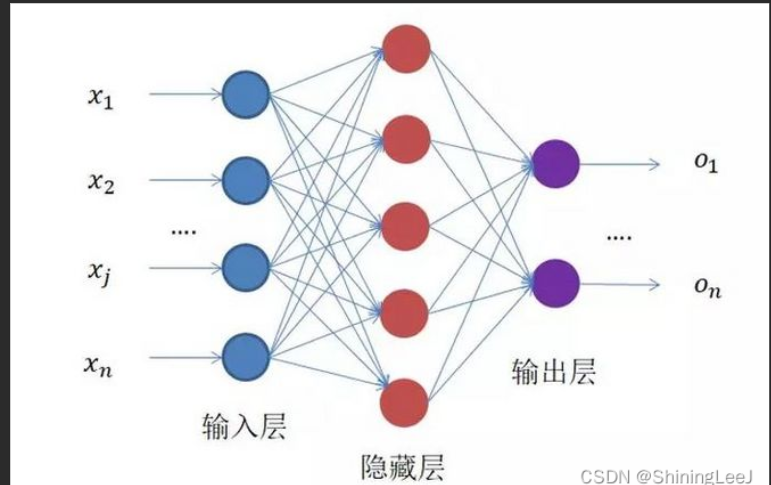

输入层 (d维)  
→ 隐藏层 (h个神经元，ReLU激活)  
→ 输出层 (c个类别，Softmax激活)


### 1.2 数学表达

设输入：$ \mathbf{x} \in \mathbb{R}^d $

第一层：
$$
\mathbf{z}^{(1)} = \mathbf{W}^{(1)}\mathbf{x} + \mathbf{b}^{(1)} \\
\mathbf{h} = \text{ReLU}(\mathbf{z}^{(1)}) = \max(0, \mathbf{z}^{(1)})
$$

第二层（输出层）：
$$
\mathbf{z}^{(2)} = \mathbf{W}^{(2)}\mathbf{h} + \mathbf{b}^{(2)} \\
\hat{\mathbf{y}} = \text{softmax}(\mathbf{z}^{(2)})_i = \frac{e^{z^{(2)}_i}}{\sum_j e^{z^{(2)}_j}}
$$

### 1.3 损失函数：交叉熵损失（Cross-Entropy Loss）

$$
L = -\frac{1}{N}\sum_{n=1}^N \sum_{c=1}^C y_{n,c} \log \hat{y}_{n,c}
$$

其中 $ y_{n,c} $ 是 one-hot 编码的真实标签。

### 1.4 反向传播核心公式（链式法则）

计算：
$$
\frac{\partial L}{\partial \mathbf{W}^{(2)}}, \frac{\partial L}{\partial \mathbf{b}^{(2)}}, 
\frac{\partial L}{\partial \mathbf{h}}, 
\frac{\partial L}{\partial \mathbf{W}^{(1)}}, \frac{\partial L}{\partial \mathbf{b}^{(1)}}
$$

关键梯度：
- 输出层：$ \frac{\partial L}{\partial \mathbf{z}^{(2)}} = \hat{\mathbf{y}} - \mathbf{y} $
- 隐藏层：$ \frac{\partial L}{\partial \mathbf{z}^{(1)}} = (\mathbf{W}^{(2)T} \cdot \delta^{(2)}) \odot \text{ReLU}'(\mathbf{z}^{(1)}) $
  其中 $ \text{ReLU}'(z) = 1(z>0) $

## 2. 代码实现

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
%matplotlib inline

np.random.seed(42)

## 3. 数据准备： moons 数据集

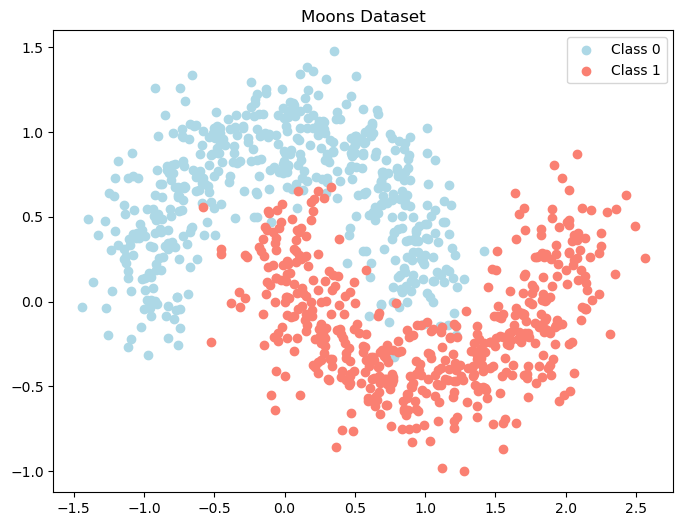

In [2]:
# 生成数据
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
y = y.reshape(-1, 1)  # 转为列向量

# 可视化
plt.figure(figsize=(8,6))
plt.scatter(X[y.ravel()==0][:,0], X[y.ravel()==0][:,1], c='lightblue', label='Class 0')
plt.scatter(X[y.ravel()==1][:,0], X[y.ravel()==1][:,1], c='salmon', label='Class 1')
plt.title("Moons Dataset")
plt.legend()
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## 4. 工具函数

In [3]:
# ReLU 及其导数
def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

# Softmax
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))  # 数值稳定
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)

# One-hot 编码
def one_hot(y, num_classes=2):
    return np.eye(num_classes)[y.ravel()].T

## 5. MLP 类实现（ NumPy）

In [4]:
class MLP:
    def __init__(self, input_size=2, hidden_size=50, output_size=2, lr=0.1):
        self.lr = lr
        # He 初始化
        self.W1 = np.random.randn(hidden_size, input_size) * np.sqrt(2. / input_size)
        self.b1 = np.zeros((hidden_size, 1))
        self.W2 = np.random.randn(output_size, hidden_size) * np.sqrt(2. / hidden_size)
        self.b2 = np.zeros((output_size, 1))
    
    def forward(self, X):
        # X: (features, samples) 即 (2, m)
        Z1 = self.W1 @ X + self.b1          # (h, m)
        H  = np.maximum(0, Z1)              # ReLU (h, m)
        Z2 = self.W2 @ H + self.b2          # (c, m)
        Y_hat = self.softmax(Z2)            # (c, m)
        return Y_hat, (X, Z1, H, Z2, Y_hat)  # 返回预测值 + 缓存
    
    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))
        return exp_z / np.sum(exp_z, axis=0, keepdims=True)
    
    def compute_loss(self, Y_hat, Y):
        m = Y.shape[1]
        loss = -np.sum(Y * np.log(Y_hat + 1e-15)) / m
        return loss
    
    def backward(self, Y, cache):
        X, Z1, H, Z2, Y_hat = cache
        m = X.shape[1]
        
        # 输出层
        dZ2 = Y_hat - Y                              # (c, m)
        dW2 = dZ2 @ H.T / m
        db2 = np.sum(dZ2, axis=1, keepdims=True) / m
        
        # 隐藏层
        dH  = self.W2.T @ dZ2                         # (h, m)
        dZ1 = dH * (Z1 > 0)                           # ReLU 导数
        dW1 = dZ1 @ X.T / m
        db1 = np.sum(dZ1, axis=1, keepdims=True) / m
        
        # 更新参数
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
    
    def predict(self, X):
        X = X.T if X.shape[0] != 2 else X  # 自动转置
        Y_hat, _ = self.forward(X)
        return np.argmax(Y_hat, axis=0)
    
    def accuracy(self, X, y):
        preds = self.predict(X)
        return np.mean(preds == y.ravel())

## 6. 训练循环 + 损失/准确率可视化

开始训练
Epoch  400 | Loss: 0.1643 | Test Acc: 95.33%
Epoch  800 | Loss: 0.0915 | Test Acc: 97.67%
Epoch 1200 | Loss: 0.0744 | Test Acc: 97.00%
Epoch 1600 | Loss: 0.0680 | Test Acc: 97.33%
Epoch 2000 | Loss: 0.0645 | Test Acc: 97.33%
Epoch 2400 | Loss: 0.0623 | Test Acc: 97.33%
Epoch 2800 | Loss: 0.0605 | Test Acc: 97.33%
训练完成！最终测试准确率：97.33%


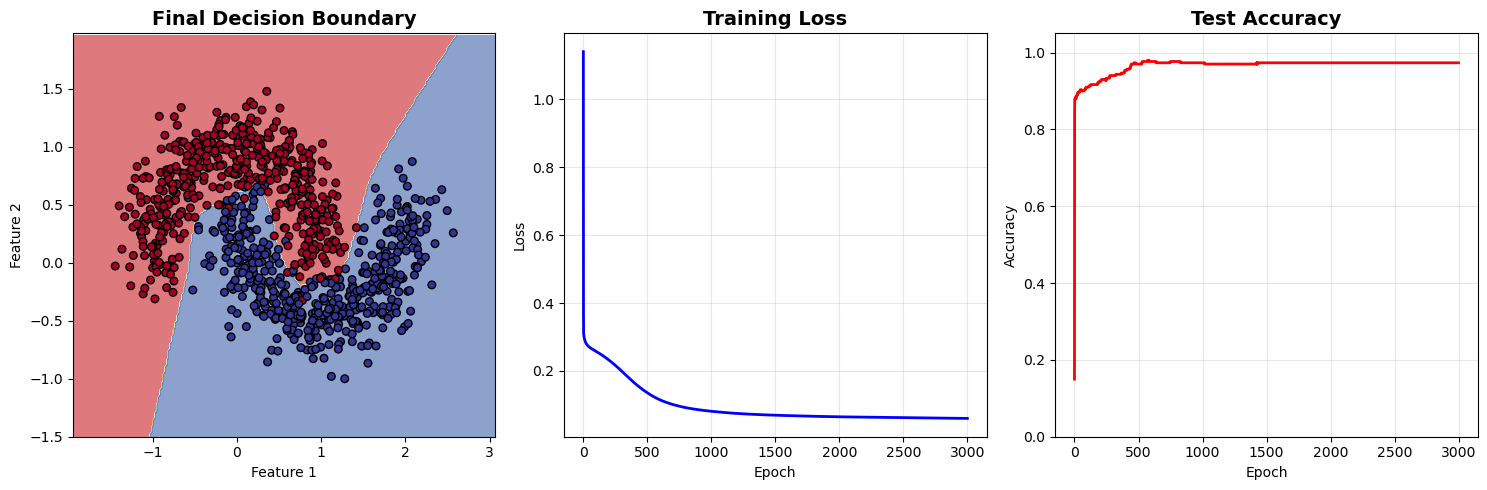

In [5]:
def one_hot(y, num_classes=2):
    return np.eye(num_classes)[y.ravel()].T

# MLP 类（用你之前的防错版）
class MLP:
    def __init__(self, input_size=2, hidden_size=100, output_size=2, lr=0.2):
        self.lr = lr
        self.W1 = np.random.randn(hidden_size, input_size) * np.sqrt(2. / input_size)
        self.b1 = np.zeros((hidden_size, 1))
        self.W2 = np.random.randn(output_size, hidden_size) * np.sqrt(2. / hidden_size)
        self.b2 = np.zeros((output_size, 1))
    
    def forward(self, X):
        Z1 = self.W1 @ X + self.b1
        H = np.maximum(0, Z1)
        Z2 = self.W2 @ H + self.b2
        Y_hat = self.softmax(Z2)
        return Y_hat, (X, Z1, H, Z2, Y_hat)
    
    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))
        return exp_z / np.sum(exp_z, axis=0, keepdims=True)
    
    def compute_loss(self, Y_hat, Y):
        m = Y.shape[1]
        loss = -np.sum(Y * np.log(Y_hat + 1e-15)) / m
        return loss
    
    def backward(self, Y, cache):
        X, Z1, H, Z2, Y_hat = cache
        m = X.shape[1]
        dZ2 = Y_hat - Y
        dW2 = dZ2 @ H.T / m
        db2 = np.sum(dZ2, axis=1, keepdims=True) / m
        dH = self.W2.T @ dZ2
        dZ1 = dH * (Z1 > 0)
        dW1 = dZ1 @ X.T / m
        db1 = np.sum(dZ1, axis=1, keepdims=True) / m
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
    
    def predict(self, X):
        X = X.T if X.shape[0] != 2 else X
        Y_hat, _ = self.forward(X)
        return np.argmax(Y_hat, axis=0)
    
    def accuracy(self, X, y):
        preds = self.predict(X)
        return np.mean(preds == y.ravel())

# 训练
mlp = MLP(input_size=2, hidden_size=100, output_size=2, lr=0.2)
X_train_T = X_train.T
Y_train_onehot = one_hot(y_train)

epochs = 3000
losses = []
accs = []

print("开始训练\n" + "="*50)
for epoch in range(epochs):
    Y_hat, cache = mlp.forward(X_train_T)
    loss = mlp.compute_loss(Y_hat, Y_train_onehot)
    acc = mlp.accuracy(X_test, y_test)
    mlp.backward(Y_train_onehot, cache)
    losses.append(loss)
    accs.append(acc)
    
    if (epoch + 1) % 400 == 0:
        print(f"Epoch {epoch+1:4d} | Loss: {loss:.4f} | Test Acc: {acc*100:5.2f}%")

print("="*50)
final_acc = mlp.accuracy(X_test, y_test)
print(f"训练完成！最终测试准确率：{final_acc*100:.2f}%")

plt.figure(figsize=(15, 5))

# 子图1: 最终决策边界
ax1 = plt.subplot(1, 3, 1)
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = mlp.predict(grid)
Z = Z.reshape(xx.shape)
ax1.contourf(xx, yy, Z, alpha=0.6, cmap='RdYlBu')
scatter = ax1.scatter(X[:,0], X[:,1], c=y.ravel(), cmap='RdYlBu', edgecolor='k', s=30)
ax1.set_title('Final Decision Boundary', fontsize=14, weight='bold')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)

# 子图2: 损失曲线
ax2 = plt.subplot(1, 3, 2)
ax2.plot(losses, color='blue', lw=2)
ax2.set_title('Training Loss', fontsize=14, weight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.grid(True, alpha=0.3)

# 子图3: 准确率曲线
ax3 = plt.subplot(1, 3, 3)
ax3.plot(accs, color='red', lw=2)
ax3.set_title('Test Accuracy', fontsize=14, weight='bold')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Accuracy')
ax3.set_ylim(0, 1.05)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 最终决策边界可视化

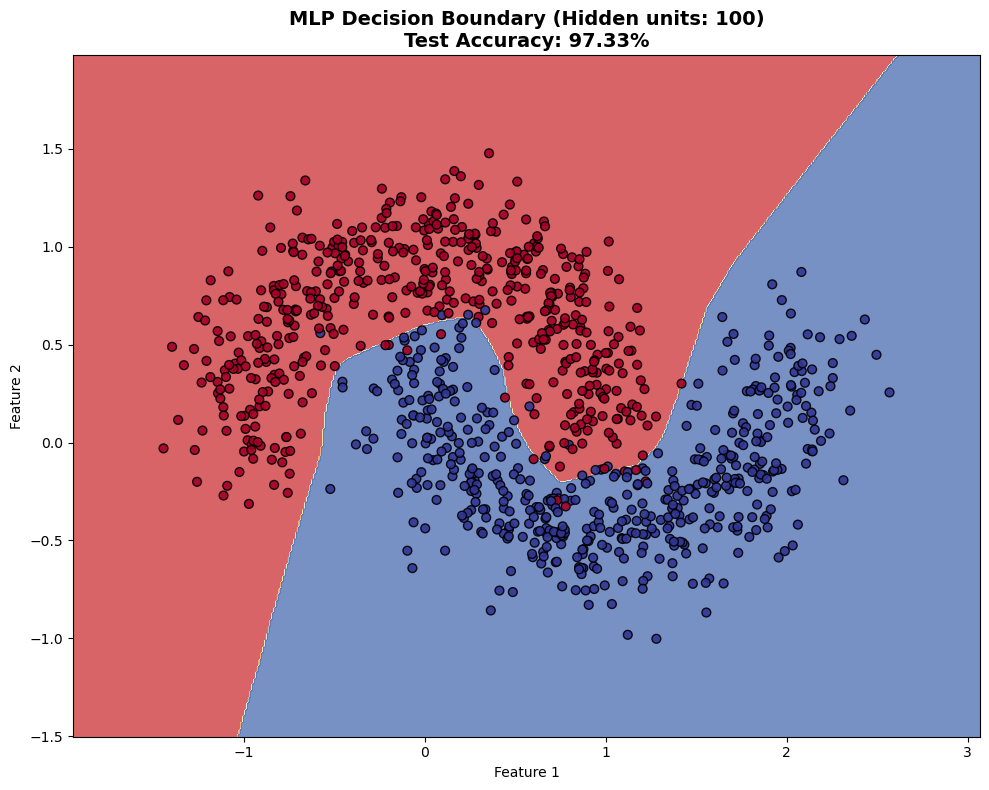

In [6]:
# 创建网格点
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))
grid = np.c_[xx.ravel(), yy.ravel()]

# 预测（确保 predict 能接受 (N, 2) 输入）
Z = mlp.predict(grid)        
Z = Z.reshape(xx.shape)

# 绘图
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, cmap='RdYlBu', alpha=0.7)   

plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), 
            cmap='RdYlBu', edgecolor='k', s=40, alpha=0.9)

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.title(f"MLP Decision Boundary (Hidden units: {mlp.W1.shape[0]})\n"
          f"Test Accuracy: {mlp.accuracy(X_test, y_test)*100:.2f}%", 
          fontsize=14, weight='bold')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()

## 总结
- MLP 的数学原理（前向、激活函数、softmax、交叉熵）
- 反向传播的链式法则和关键梯度公式
- 使用纯 NumPy 从零实现一个可训练的神经网络
- 参数初始化（He 初始化）、数值稳定技巧
- 可视化损失、准确率、决策边界